In [1]:
# ========================================
# CELL 1 — Install Qwen2-VL Dependencies
# ========================================

!pip install -q transformers accelerate
!pip install -q pillow opencv-python
!pip install -q qwen-vl-utils
!pip install -q sentencepiece

print("✅ Qwen2-VL Dependencies Installed Successfully")

✅ Qwen2-VL Dependencies Installed Successfully


In [3]:
# ========================================
# CELL 2.1 — Upgrade Transformers
# ========================================

!pip install -U transformers accelerate

print("✅ Transformers Updated Successfully")

✅ Transformers Updated Successfully


In [2]:
# ========================================
# CELL 2 — Load Qwen2-VL-2B (Stable Method)
# ========================================

import torch
from transformers import AutoTokenizer, AutoModel

model_name = "Qwen/Qwen2-VL-2B-Instruct"

print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(
    model_name,
    trust_remote_code=True
)

print("Loading model...")

model = AutoModel.from_pretrained(
    model_name,
    trust_remote_code=True,
    device_map="cpu",
    torch_dtype=torch.float32
)

model = model.eval()

print("✅ Qwen2-VL-2B Loaded Successfully")

Loading tokenizer...
Loading model...


`torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 729/729 [00:01<00:00, 631.32it/s]


✅ Qwen2-VL-2B Loaded Successfully


✅ Image Loaded Successfully


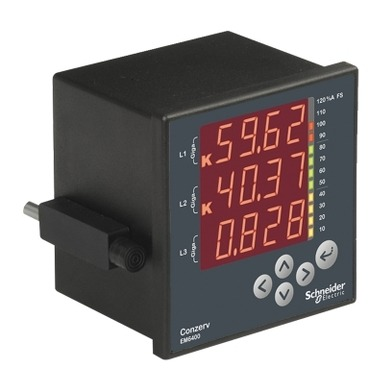

In [3]:
# ========================================
# CELL 3 — Load Energy Meter Image
# ========================================

from PIL import Image

# Put your image path here
image_path = "ener.jpeg"

image = Image.open(image_path).convert("RGB")

print("✅ Image Loaded Successfully")

display(image)

In [11]:
# ========================================
# CELL 7 — Final Qwen2-VL Inference
# ========================================

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image"},
            {"type": "text", "text": "Read the energy meter value. Return only numbers."}
        ]
    }
]

text = processor.apply_chat_template(
    messages,
    add_generation_prompt=True
)

inputs = processor(
    text=[text],
    images=[image],
    return_tensors="pt"
)

outputs = model.generate(
    **inputs,
    max_new_tokens=50
)

response = processor.batch_decode(
    outputs,
    skip_special_tokens=True
)[0]

print("Raw Output:")
print(response)

Raw Output:
system
You are a helpful assistant.
user
Read the energy meter value. Return only numbers.
assistant
59.62, 40.37, 0.82
